Top 10 wichtigste Felder:
                             Feature  Wichtigkeit
8242                     cat__cat_A1     0.055213
8243                     cat__cat_A2     0.034492
8250                     cat__cat_O1     0.016169
218     cat__country_Unknown country     0.012220
8247                     cat__cat_H2     0.008998
215                 cat__country_USA     0.008521
8252                     cat__cat_U1     0.008472
5008             cat__operator_USAAF     0.008102
8244                     cat__cat_C1     0.006696
6879  cat__type_Douglas C-47A (DC-3)     0.005966


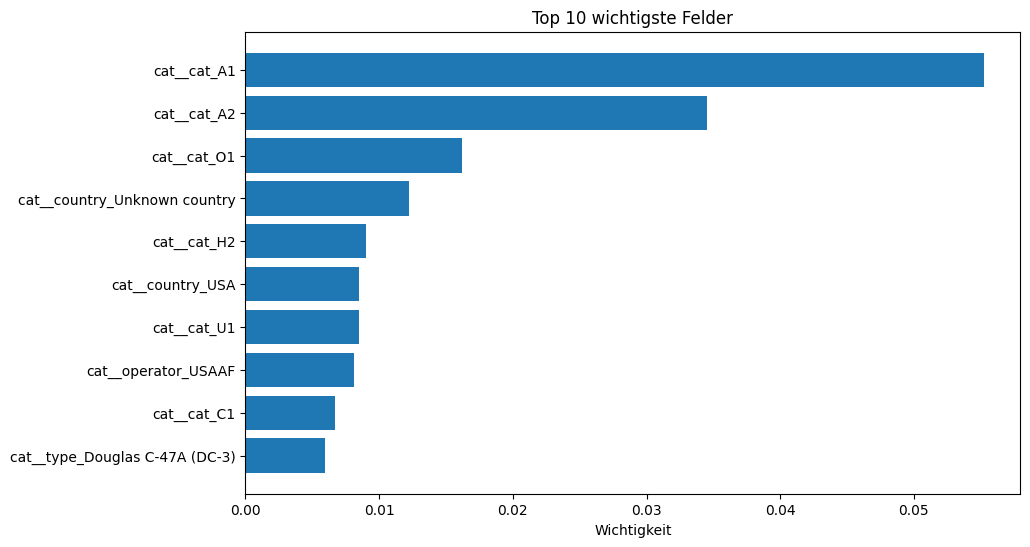

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    df = pd.read_csv("aviation-accident.csv", sep=";", encoding="latin1")
except:
    df = pd.read_csv("aviation-accident.csv", sep=";", encoding="cp1252")

df.columns = df.columns.str.strip().str.lower()
df["fatalities"] = pd.to_numeric(df["fatalities"], errors="coerce").fillna(0)
df["year"] = pd.to_numeric(df["year"], errors="coerce").fillna(df["year"].median())

df["fatal_accident"] = (df["fatalities"] > 0).astype(int)

features = ["country", "operator", "type", "cat", "year"]
X = df[features].fillna("Unknown")
y = df["fatal_accident"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Wichtigkeit": importances
}).sort_values(by="Wichtigkeit", ascending=False)

print("Top 10 wichtigste Felder:")
print(feature_importance_df.head(10).to_string())

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df["Feature"].head(10),
    feature_importance_df["Wichtigkeit"].head(10)
)
plt.gca().invert_yaxis()
plt.title("Top 10 wichtigste Felder")
plt.xlabel("Wichtigkeit")
plt.show()

In [7]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.703059513830679
              precision    recall  f1-score   support

           0       0.75      0.79      0.77      2989
           1       0.61      0.55      0.58      1783

    accuracy                           0.70      4772
   macro avg       0.68      0.67      0.68      4772
weighted avg       0.70      0.70      0.70      4772



Confusion Matrix:
[[2375  614]
 [ 803  980]]
Sensitivität: 0.5496354458777342
Spezifizität: 0.7945801271328203


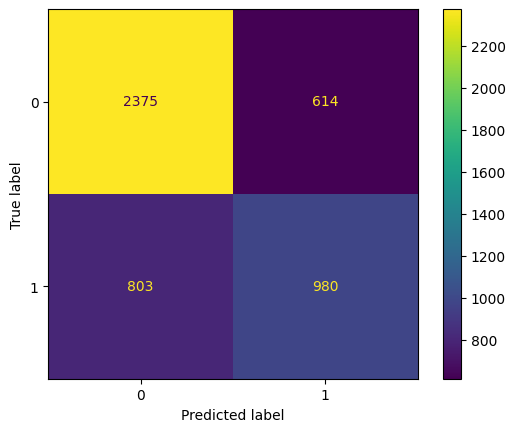

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivität:", sensitivity)
print("Spezifizität:", specificity)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
# 4.4 Zusammenfassung (50–100 Wörter)

#Das Modell erreicht eine Accuracy von etwa 70 % und liefert damit
#insgesamt brauchbare Resultate. Nicht tödliche Unfälle werden etwas
#zuverlässiger erkannt als tödliche, was die niedrigere Sensitivität zeigt.
#Dies könnte daran liegen, dass es weniger Datensätze mit tödlichen Unfälle hat und somit weniger Informationen gibt. Besonders Flugzeugtyp, 
#Betreiber und Unfallkategorie liefern wertvolle Hinweise ob ein Unfall Tödlich ist oder nicht.
#Mit zusätzlichen Datenfeldern und präziseren Informationen könnte
#die Vorhersagegenauigkeit des Modells weiter verbessert werden.